Imports & Global Settings

Explanation (English): Import all required libraries and set global parameters (observation window length, device, random seeds).

In [21]:
!pip install nn
!pip install dataset
!pip install dataloader

In [6]:
import os
import glob
import random
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = "data_real/raw"
SCENE = "hotel"



In [32]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Sliding window settings
OBS_LEN = 10          # number of observed points
PRED_LEN = 1          # next-step prediction

# Training settings
BATCH_SIZE = 256

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


DEVICE: cpu


Define Dataset Root and Scene

Explanation (English): Point to the folder containing ETH/UCY scenes and choose which scene to train on (e.g., hotel).

In [33]:
import os

DATA_ROOT = "data_real/raw"
SCENE = "hotel"  # "eth", "hotel", "univ", "zara01", "zara02"

scene_dir = os.path.join(DATA_ROOT, SCENE)

print("Scene directory:", scene_dir)
print("Exists:", os.path.exists(scene_dir))

if os.path.exists(scene_dir):
    print("Contents:", os.listdir(scene_dir))


Scene directory: data_real/raw\hotel
Exists: True
Contents: ['test', 'train', 'val']


Verifying dataset structure and official splits

Explanation (EN)
This cell verifies that the dataset follows the official ETH/UCY structure with predefined train, validation, and test splits. Respecting this structure avoids data leakage.

In [34]:
scene_dir = os.path.join(DATA_ROOT, SCENE)

assert os.path.exists(scene_dir), "Scene directory not found"

for split in ["train", "val", "test"]:
    split_dir = os.path.join(scene_dir, split)
    print(f"{split.upper()} exists:", os.path.exists(split_dir))
    print(" Files:", os.listdir(split_dir))


TRAIN exists: True
 Files: ['biwi_eth_train.txt', 'crowds_zara01_train.txt', 'crowds_zara02_train.txt', 'crowds_zara03_train.txt', 'students001_train.txt', 'students003_train.txt', 'uni_examples_train.txt']
VAL exists: True
 Files: ['biwi_eth_val.txt', 'crowds_zara01_val.txt', 'crowds_zara02_val.txt', 'crowds_zara03_val.txt', 'students001_val.txt', 'students003_val.txt', 'uni_examples_val.txt']
TEST exists: True
 Files: ['biwi_hotel.txt']


Loading raw pedestrian trajectory files

Explanation (EN)
Each text file contains pedestrian trajectories in the format:
frame_id, pedestrian_id, x, y.
All files from a given split are concatenated into a single DataFrame.

In [35]:
import os
import pandas as pd

def load_split(scene: str, split: str, data_root="data_real/raw"):
    split_dir = os.path.join(data_root, scene, split)
    dfs = []

    for fname in sorted(os.listdir(split_dir)):
        path = os.path.join(split_dir, fname)

        # ✅ robust reading: spaces/tabs/multiple spaces
        df = pd.read_csv(
            path,
            delim_whitespace=True,   # <--- IMPORTANT
            header=None,
            names=["frame", "pid", "x", "y"],
            engine="python"
        )

        dfs.append(df)

    df_all = pd.concat(dfs, ignore_index=True)

    # ✅ Force numeric types (after correct parsing)
    for c in ["frame", "pid", "x", "y"]:
        df_all[c] = pd.to_numeric(df_all[c], errors="coerce")

    # ✅ remove bad rows
    df_all = df_all.dropna(subset=["frame", "pid", "x", "y"])

    return df_all


Temporal consistency and dataset statistics

Explanation (EN)
This cell verifies temporal ordering, frame spacing, and the number of pedestrians.
ETH/UCY datasets typically use a frame step of 10.

In [36]:
SCENE = "hotel"
df_train = load_split(SCENE, "train")
df_val   = load_split(SCENE, "val")

print("Train samples:", len(df_train))
print("Val samples:", len(df_val))

print("Frame range:", df_train["frame"].min(), "->", df_train["frame"].max())
print("Unique pedestrians:", df_train["pid"].nunique())
print("Unique frames:", df_train["frame"].nunique())


C:\Users\kamen\AppData\Local\Temp\ipykernel_28428\4012703056.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\kamen\AppData\Local\Temp\ipykernel_28428\4012703056.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\kamen\AppData\Local\Temp\ipykernel_28428\4012703056.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\kamen\AppData\Local\Temp\ipykernel_28428\4012703056.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\kamen\AppData\Local\Temp\ipykernel_28428\4012703056.py:12: FutureWarnin

Train samples: 55562
Val samples: 12323
Frame range: 0.0 -> 10230.0
Unique pedestrians: 429
Unique frames: 1024


C:\Users\kamen\AppData\Local\Temp\ipykernel_28428\4012703056.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\kamen\AppData\Local\Temp\ipykernel_28428\4012703056.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\kamen\AppData\Local\Temp\ipykernel_28428\4012703056.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\kamen\AppData\Local\Temp\ipykernel_28428\4012703056.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\kamen\AppData\Local\Temp\ipykernel_28428\4012703056.py:12: FutureWarnin

Grouping positions into pedestrian trajectories

Explanation (EN)
Each pedestrian trajectory is represented as a sequence of (frame, x, y) ordered in time.

In [37]:
# 1. On force la conversion en numérique pour éviter l'erreur 'str' - 'str'
df_train["frame"] = pd.to_numeric(df_train["frame"], errors='coerce')
df_train["pid"] = pd.to_numeric(df_train["pid"], errors='coerce')

# 2. On nettoie les lignes vides (NaN) créées par une mauvaise lecture
df_train = df_train.dropna(subset=["frame", "pid"])

# 3. Vérification de sécurité pour éviter l'IndexError
if not df_train.empty:
    print("Frame range:", df_train["frame"].min(), "→", df_train["frame"].max())
    print("Unique pedestrians:", df_train["pid"].nunique())
    
    # Tri et création du dictionnaire de trajectoires
    df_sorted = df_train.sort_values(["pid", "frame"])
    traj_by_pid = {
        int(pid): g[["frame", "x", "y"]].to_numpy()
        for pid, g in df_sorted.groupby("pid")
    }

    # On vérifie si le dictionnaire n'est pas vide avant d'accéder à l'index [0]
    if traj_by_pid:
        example_pid = list(traj_by_pid.keys())[0]
        print(f"Trajectory shape for PID {example_pid}:", traj_by_pid[example_pid].shape)
    else:
        print("⚠️ Aucune trajectoire générée. Vérifiez vos données 'pid'.")
else:
    print("❌ ERREUR : Le DataFrame est vide après nettoyage. Vérifiez le chargement du CSV.")


Frame range: 0.0 → 10230.0
Unique pedestrians: 429
Trajectory shape for PID 1: (163, 3)


In [38]:
df_sorted = df_train.sort_values(["pid", "frame"]).reset_index(drop=True)

traj_by_pid = {
    int(pid): g[["frame", "x", "y"]].to_numpy()
    for pid, g in df_sorted.groupby("pid")
}

print("Num pedestrians in dict:", len(traj_by_pid))
first_pid = list(traj_by_pid.keys())[0]
print("Example PID:", first_pid, "traj shape:", traj_by_pid[first_pid].shape)
print(traj_by_pid[first_pid][:5])


Num pedestrians in dict: 429
Example PID: 1 traj shape: (163, 3)
[[ 0.         13.44872051  3.9378867 ]
 [ 0.         12.77523215  7.27912389]
 [ 0.         11.23883685  3.74695886]
 [ 0.          9.04999971  6.03809293]
 [ 0.          0.29465115  8.09056721]]


Creating supervised LSTM samples using sliding windows

Explanation (EN)
Each input sample consists of 10 consecutive (x, y) positions, and the target is the next position.
Overlapping windows are used to maximize data usage.

In [39]:
X_list, Y_list = [], []

for traj in traj_by_pid.values():
    coords = traj[:, 1:3]  # keep only x, y

    if len(coords) <= OBS_LEN:
        continue

    for t in range(len(coords) - OBS_LEN):
        X_list.append(coords[t:t+OBS_LEN])
        Y_list.append(coords[t+OBS_LEN])

X = np.stack(X_list)
Y = np.stack(Y_list)

print("X shape:", X.shape)
print("Y shape:", Y.shape)


X shape: (51288, 10, 2)
Y shape: (51288, 2)


Visualizing pedestrian motion trajectories

Explanation (EN)
This visualization helps intuitively understand pedestrian motion patterns before training the LSTM.

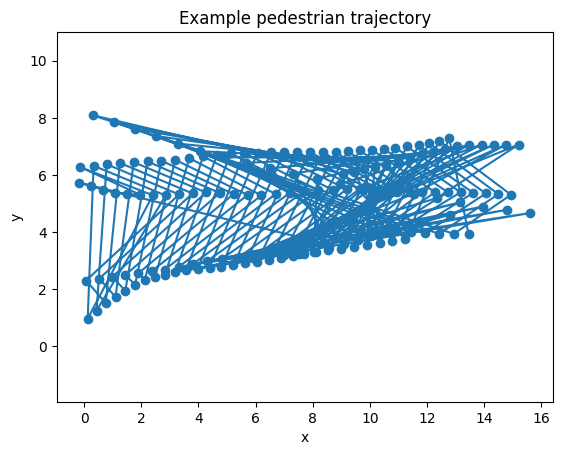

In [40]:
pid = list(traj_by_pid.keys())[0]
traj = traj_by_pid[pid]

plt.plot(traj[:,1], traj[:,2], marker="o")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Example pedestrian trajectory")
plt.axis("equal")
plt.show()


Build sliding-window samples for TRAIN and VAL

Explanation (EN): We convert raw trajectories into supervised samples. Each input is a window of OBS_LEN consecutive (x,y) positions, and the target is the next (x,y) position. We do this separately for train and validation splits (no extra splitting).

In [41]:
import numpy as np

OBS_LEN = 10  # input sequence length

def build_traj_dict(df):
    # Ensure numeric + clean
    df = df.copy()
    df["frame"] = pd.to_numeric(df["frame"], errors="coerce")
    df["pid"]   = pd.to_numeric(df["pid"], errors="coerce")
    df["x"]     = pd.to_numeric(df["x"], errors="coerce")
    df["y"]     = pd.to_numeric(df["y"], errors="coerce")
    df = df.dropna(subset=["frame", "pid", "x", "y"])

    df_sorted = df.sort_values(["pid", "frame"]).reset_index(drop=True)
    traj_by_pid = {
        int(pid): g[["frame", "x", "y"]].to_numpy()
        for pid, g in df_sorted.groupby("pid")
    }
    return traj_by_pid

def build_windows(traj_by_pid, obs_len=10):
    X_list, Y_list = [], []
    for traj in traj_by_pid.values():
        coords = traj[:, 1:3]  # keep only x,y
        if len(coords) <= obs_len:
            continue
        for t in range(len(coords) - obs_len):
            X_list.append(coords[t:t+obs_len])   # (obs_len, 2)
            Y_list.append(coords[t+obs_len])     # (2,)
    X = np.stack(X_list) if len(X_list) else np.zeros((0, obs_len, 2), dtype=np.float32)
    Y = np.stack(Y_list) if len(Y_list) else np.zeros((0, 2), dtype=np.float32)
    return X.astype(np.float32), Y.astype(np.float32)

# Build TRAIN
traj_train = build_traj_dict(df_train)
X_train, Y_train = build_windows(traj_train, OBS_LEN)

# Build VAL
traj_val = build_traj_dict(df_val)
X_val, Y_val = build_windows(traj_val, OBS_LEN)

print("Train windows:", X_train.shape, Y_train.shape)
print("Val windows:  ", X_val.shape, Y_val.shape)


Train windows: (51288, 10, 2) (51288, 2)
Val windows:   (9557, 10, 2) (9557, 2)


Optional: Build TEST windows (final evaluation)

Explanation (EN): The test split is used only at the end to report final performance. We build sliding windows for test exactly like train/val.

In [42]:
df_test = load_split(SCENE, "test")

traj_test = build_traj_dict(df_test)
X_test, Y_test = build_windows(traj_test, OBS_LEN)

print("Test windows:", X_test.shape, Y_test.shape)


Test windows: (3090, 10, 2) (3090, 2)


C:\Users\kamen\AppData\Local\Temp\ipykernel_28428\4012703056.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


PyTorch Dataset and DataLoaders

Explanation (EN): We wrap the numpy arrays into PyTorch datasets and create DataLoaders for mini-batch training.

In [43]:
import torch
from torch.utils.data import Dataset, DataLoader

class TrajDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)  # (N, T, 2)
        self.Y = torch.from_numpy(Y)  # (N, 2)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

batch_size = 256

train_loader = DataLoader(TrajDataset(X_train, Y_train), batch_size=batch_size, shuffle=True, drop_last=False)
val_loader   = DataLoader(TrajDataset(X_val, Y_val),     batch_size=batch_size, shuffle=False, drop_last=False)

test_loader  = DataLoader(TrajDataset(X_test, Y_test),   batch_size=batch_size, shuffle=False, drop_last=False) if len(X_test) else None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


Define the LSTM model

Explanation (EN): This model reads a sequence of 2D positions and outputs the next 2D position. It is a simple but strong baseline.

In [44]:
import torch.nn as nn

class NextStepLSTM(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        # x: (B, T, 2)
        out, _ = self.lstm(x)         # out: (B, T, H)
        last = out[:, -1, :]          # (B, H)
        pred = self.fc(last)          # (B, 2)
        return pred

model = NextStepLSTM(input_dim=2, hidden_dim=64, num_layers=1, dropout=0.0).to(device)
print(model)


NextStepLSTM(
  (lstm): LSTM(2, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


Metrics: MSE + ADE + Acc@k

Explanation (EN): MSE is the training loss. ADE is the average Euclidean distance (interpretable in “meters-like” units after normalization). Acc@k measures the percentage of predictions within distance k.

In [45]:
import math

def batch_mse(pred, target):
    return torch.mean((pred - target) ** 2)

def batch_ade(pred, target):
    # Euclidean distance per sample, then mean
    return torch.mean(torch.sqrt(torch.sum((pred - target) ** 2, dim=1) + 1e-9))

@torch.no_grad()
def batch_acc_at_k(pred, target, k):
    dist = torch.sqrt(torch.sum((pred - target) ** 2, dim=1) + 1e-9)
    return torch.mean((dist <= k).float())


Training loop (with best checkpoint on VAL)

Explanation (EN): We train on TRAIN, monitor VAL, and keep the model with the best validation ADE (or MSE). This prevents overfitting and gives a fair comparison.

In [55]:
pip install ipywidgets


Note: you may need to restart the kernel to use updated packages.


In [53]:
import os
from tqdm.notebook import tqdm

lr = 1e-4
epochs = 100

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

os.makedirs("models", exist_ok=True)
best_path = f"models/lstm_real_{SCENE}_best.pth"

history = {
    "train_mse": [],
    "val_mse": [],
    "train_ade": [],
    "val_ade": []
}

best_val_ade = float("inf")

for ep in range(1, epochs + 1):
    # ---- TRAIN ----
    model.train()
    train_mse_sum, train_ade_sum, n_train = 0.0, 0.0, 0

    for xb, yb in tqdm(train_loader, desc=f"Epoch {ep}/{epochs} [train]", leave=False):
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)

        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        bsz = xb.size(0)
        train_mse_sum += loss.item() * bsz
        train_ade_sum += batch_ade(pred, yb).item() * bsz
        n_train += bsz

    train_mse = train_mse_sum / max(n_train, 1)
    train_ade = train_ade_sum / max(n_train, 1)

    # ---- VAL ----
    model.eval()
    val_mse_sum, val_ade_sum, n_val = 0.0, 0.0, 0

    with torch.no_grad():
        for xb, yb in tqdm(val_loader, desc=f"Epoch {ep}/{epochs} [val]", leave=False):
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)

            loss = criterion(pred, yb)
            ade = batch_ade(pred, yb)

            bsz = xb.size(0)
            val_mse_sum += loss.item() * bsz
            val_ade_sum += ade.item() * bsz
            n_val += bsz

    val_mse = val_mse_sum / max(n_val, 1)
    val_ade = val_ade_sum / max(n_val, 1)

    history["train_mse"].append(train_mse)
    history["val_mse"].append(val_mse)
    history["train_ade"].append(train_ade)
    history["val_ade"].append(val_ade)

    print(f"Epoch {ep:03d} | train MSE={train_mse:.6f} ADE={train_ade:.6f} || val MSE={val_mse:.6f} ADE={val_ade:.6f}")

    # Save best
    if val_ade < best_val_ade:
        best_val_ade = val_ade
        torch.save(model.state_dict(), best_path)
        print(f"  ✅ Saved best model to {best_path} (val ADE={best_val_ade:.6f})")


Epoch 1/100 [train]:   0%|          | 0/201 [00:00<?, ?it/s]

Epoch 1/100 [val]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 001 | train MSE=52.205825 ADE=9.592037 || val MSE=33.052320 ADE=7.523224
  ✅ Saved best model to models/lstm_real_hotel_best.pth (val ADE=7.523224)


Epoch 2/100 [train]:   0%|          | 0/201 [00:00<?, ?it/s]

Epoch 2/100 [val]:   0%|          | 0/38 [00:00<?, ?it/s]

...

Epoch 99/100 [val]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 099 | train MSE=2.039929 ADE=0.948587 || val MSE=1.115607 ADE=0.611540


Epoch 100/100 [train]:   0%|          | 0/201 [00:00<?, ?it/s]

Epoch 100/100 [val]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 100 | train MSE=2.033962 ADE=0.946012 || val MSE=1.125123 ADE=0.617597


Plot learning curves

Explanation (EN): The curves help diagnose overfitting: if train improves but val worsens, the model is overfitting.

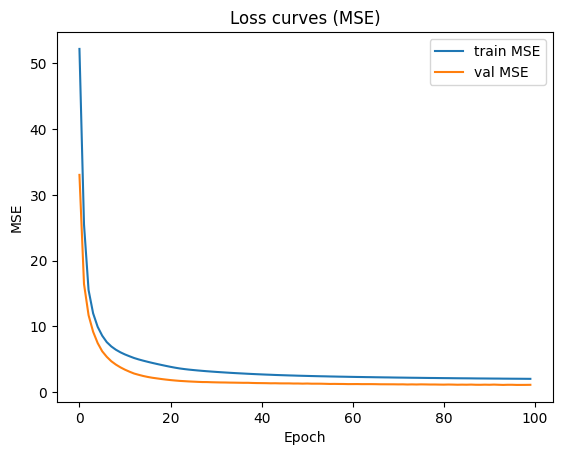

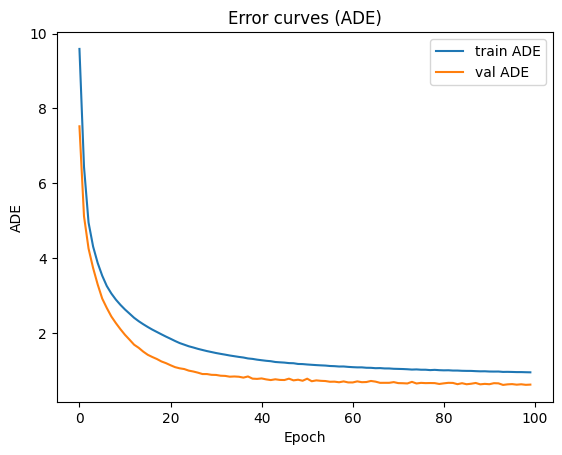

In [54]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history["train_mse"], label="train MSE")
plt.plot(history["val_mse"], label="val MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Loss curves (MSE)")
plt.legend()
plt.show()

plt.figure()
plt.plot(history["train_ade"], label="train ADE")
plt.plot(history["val_ade"], label="val ADE")
plt.xlabel("Epoch")
plt.ylabel("ADE")
plt.title("Error curves (ADE)")
plt.legend()
plt.show()
